# 実践プロジェクト_アヤメの品種データ分析

## 分析目標

本データ分析レポートの目的は、アヤメの属性データに基づき、2種類のアヤメについて、がく片および花弁の長さと幅の平均値に有意差があるかを分析し、異なる品種のアヤメが持つ属性上の特徴を推測することである。

## 概要

元データの`Iris.csv`には、2種類のアヤメが含まれており、各種類につき50件、合計100件のサンプルが収録されている。また、各サンプルには、がく片の長さと幅、花弁の長さと幅などの属性が含まれている。

`Iris.csv`の各列の意味は以下のとおりである。

* `Id`：サンプルのID
* `SepalLengthCm`：がく片の長さ（単位：cm）
* `SepalWidthCm`：がく片の幅（単位：cm）
* `PetalLengthCm`：花弁の長さ（単位：cm）
* `PetalWidthCm`：花弁の幅（単位：cm）
* `Species`：アヤメの種類

## データの読み込み

データ分析に必要なライブラリをインポートし、Pandasのread_csv関数を使用して、元データファイルIris.csvのデータをDataFrameとして読み込み、変数original_dataに代入する。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_data = pd.read_csv("Iris.csv")

In [3]:
original_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## データの評価とクリーニング

前のセクションで作成した`original_data`DataFrameに含まれるデータを評価し、クリーニングする。

主に、データの構造と内容という2つの観点、すなわち整然性と清潔性の観点から確認する。

データの構造上の問題とは、「各変数を1列にする」「各観測値を1行にする」「各種類の観測単位を1つの表にまとめる」という3つの基準を満たしていない状態を指す。データの内容上の問題には、欠損データ、重複データ、無効なデータなどが含まれる。


クリーニング後のデータと元データを区別するため、新しい変数cleaned_dataを作成し、original_dataのコピーを代入する。以降のクリーニング処理は、すべてcleaned_dataに対して実行する。

In [4]:
cleaned_data = original_data.copy()

### データの整然性

In [5]:
cleaned_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


先頭10行のデータを見ると、「各変数を1列にする」「各観測値を1行にする」「各種類の観測単位を1つの表にまとめる」という基準を満たしているため、構造上の問題は存在しない。

### データの清潔性

次に、`info`を使用してデータの内容をおおまかに確認する。

In [6]:
cleaned_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 4.8 KB


出力結果から、cleaned_dataには100件の観測値があり、欠損値は存在しないことが分かる。

IdはサンプルIDを表すため、データ型は数値型ではなく文字列型であることが適切である。そのため、データ型を変換する必要がある。

In [7]:
cleaned_data["Id"] = cleaned_data["Id"].astype("str")
cleaned_data["Id"]

0       1
1       2
2       3
3       4
4       5
     ... 
95     96
96     97
97     98
98     99
99    100
Name: Id, Length: 100, dtype: str

#### 重複データの処理

データの各変数の意味と内容から、cleaned_dataのIdは各サンプルを一意に識別する識別子であり、重複してはならない。そのため、重複値が存在するかを確認する。

In [8]:
cleaned_data["Id"].duplicated().sum()

np.int64(0)

出力結果が0であるため、重複値は存在しない。

#### 不整合データの処理

不整合なデータはSpecies変数に存在する可能性があるため、同じアヤメの種類を示す複数の異なる値が存在するかを確認する。

In [9]:
cleaned_data["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64

以上の出力結果から、`Species`には`Iris-versicolor`と`Iris-setosa`の2種類の値しか存在せず、不整合なデータは存在しない。

この列のデータ型は`category`型に変換できる。文字列型よりもメモリ使用量を削減でき、値の種類が限定されていることも明確に示せる。

In [10]:
cleaned_data["Species"] = cleaned_data["Species"].astype("category")
cleaned_data["Species"]

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
           ...       
95    Iris-versicolor
96    Iris-versicolor
97    Iris-versicolor
98    Iris-versicolor
99    Iris-versicolor
Name: Species, Length: 100, dtype: category
Categories (2, str): ['Iris-setosa', 'Iris-versicolor']

#### 無効または誤ったデータの処理

DataFrameの`describe`メソッドを使用すると、数値データの統計情報をすばやく確認できる。

In [11]:
cleaned_data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,100.000000,100.000000,100.000000,100.000000
mean,5.471000,3.094000,2.862000,0.785000
std,0.641698,0.476057,1.448565,0.566288
min,4.300000,2.000000,1.000000,0.100000
25%,5.000000,2.800000,1.500000,0.200000
50%,5.400000,3.050000,2.450000,0.800000
75%,5.900000,3.400000,4.325000,1.300000
max,7.000000,4.400000,5.100000,1.800000


## データの整理

データの整理方法は、分析の方向性と密接に関係している。今回のデータ分析の目的は、アヤメの属性データに基づき、2種類のアヤメについて、がく片および花弁の長さと幅の平均値に有意差があるかを分析することである。

そのため、`Species`列を基準に、各種類のアヤメのサンプルデータを抽出する。

In [12]:
iris_setosa = cleaned_data.query('Species == "Iris-setosa"')
iris_setosa.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [13]:
len(iris_setosa)

50

In [14]:
iris_versicolor = cleaned_data.query('Species == "Iris-versicolor"')
iris_versicolor.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
53,54,5.5,2.3,4.0,1.3,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor


In [15]:
len(iris_versicolor)

50

## データの探索

推測統計学による分析に着手する前に、データの可視化を利用して、`Setosa`と`Versicolor`という2種類のアヤメが持つ変数の特徴を探索する。

可視化による探索を行うことで、データの分布や変数間の関係などを直感的に把握でき、その後の詳細な分析の方向性を定めるための手がかりを得られる。

数値データについては、ペアプロットを作成し、対角線上の密度プロットから各変数の分布を確認し、散布図から変数間の関係を把握できる。

また、今回の分析目的は、アヤメの種類によって属性の特徴に差があるかを明らかにすることである。そのため、色分けを利用して、グラフ上のサンプルを種類別に分類する。

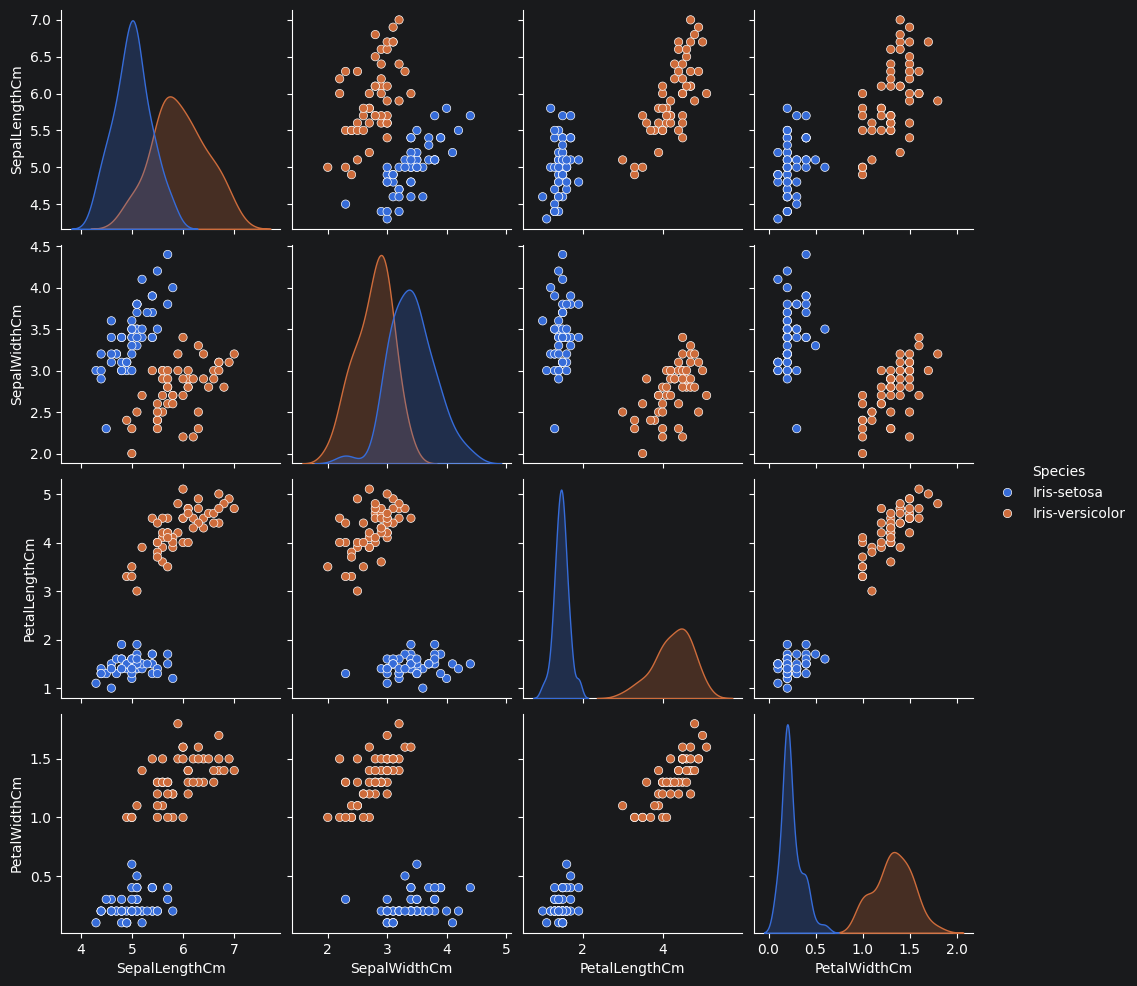

In [16]:
sns.pairplot(cleaned_data, hue="Species")
plt.show()

以上から、`Setosa`と`Versicolor`の花弁の長さおよび花弁の幅の分布には、数値上の明確な違いが見られる。そのため、仮説検定の結果についても、2種類のアヤメの花弁の長さと幅には統計的に有意な差があると予想できる。

一方、がく片の長さと幅の分布には重なりが見られるため、グラフだけでは結論を出せない。母集団におけるがく片の長さと幅に差があるかどうかを推測するには、仮説検定を行う必要がある。

## データ分析

仮説検定を用いて、`Setosa`と`Versicolor`の2種類のアヤメについて、がく片と花弁の長さおよび幅の平均値に統計的に有意な差があるかを順に検定する。

標本データしかなく、母標準偏差が不明である。また、2群の標本数はそれぞれ50であり、標本数もそれほど多くないため、z検定ではなくt検定を行う。

このデータセットの標本は、t検定の2つの前提である「無作為抽出された標本であること」と「母集団が正規分布に従うこと」を満たしていると仮定する。

まず、t検定に必要なモジュールをインポートする。

In [17]:
from scipy.stats import ttest_ind

### がく片の長さの分析

`Setosa`と`Versicolor`のがく片の長さの分布は、以下のとおりである。

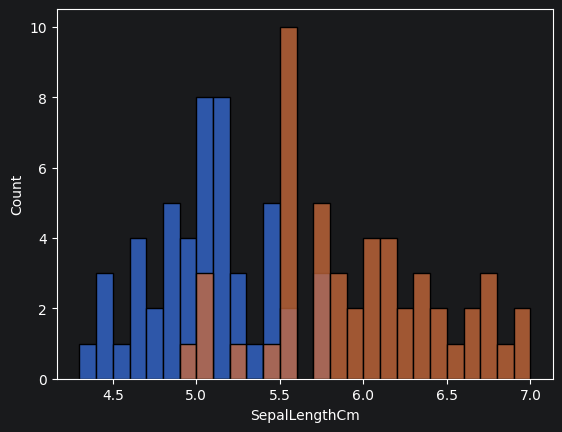

In [24]:
sns.histplot(iris_setosa["SepalLengthCm"], binwidth=0.1)
sns.histplot(iris_versicolor["SepalLengthCm"], binwidth=0.1)
plt.show()

### 仮説の設定

$H_0$：`Setosa`と`Versicolor`のがく片の長さの平均値に有意な差はない。

$H_1$：`Setosa`と`Versicolor`のがく片の長さの平均値に有意な差がある。


#### 片側検定か両側検定かを確認する

平均値に差があるかどうかだけを検定し、どちらの品種のがく片が長いかは問題にしないため、両側検定を行う。


#### 有意水準の設定

有意水準を0.05に設定する。


#### t値とp値の計算

In [26]:
t_stat, p_value = ttest_ind(iris_setosa["SepalLengthCm"], iris_versicolor["SepalLengthCm"])
print(t_stat, p_value)

-10.52098626754911 8.985235037487147e-18


結論：p値が有意水準0.05を下回るため、帰無仮説を棄却する。したがって、`Setosa`と`Versicolor`のがく片の長さの平均値には統計的に有意な差がある。

### がく片の幅の分析

`Setosa`と`Versicolor`のがく片の長さの分布は、以下のとおりである。


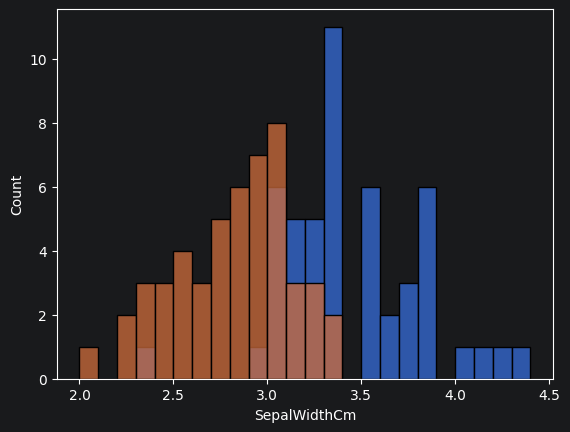

In [27]:
sns.histplot(iris_setosa["SepalWidthCm"], binwidth=0.1)
sns.histplot(iris_versicolor["SepalWidthCm"], binwidth=0.1)
plt.show()

仮説の設定

$H_0$：SetosaとVersicolorのがく片の幅の平均値に有意な差はない。

$H_1$：SetosaとVersicolorのがく片の幅の平均値に有意な差がある。

片側検定か両側検定かを確認する

平均値に差があるかどうかだけを検定し、どちらの品種のがく片が広いかは問題にしないため、両側検定を行う。

有意水準の設定

有意水準を0.05に設定する。

#### t値とp値の計算

In [28]:
t_stat, p_value = ttest_ind(iris_setosa["SepalWidthCm"], iris_versicolor["SepalWidthCm"])
print(t_stat, p_value)

9.282772555558111 4.3622390160102135e-15


結論：p値が有意水準0.05を下回るため、帰無仮説を棄却する。したがって、SetosaとVersicolorのがく片の幅の平均値には統計的に有意な差がある。

### 花弁の長さの分析

SetosaとVersicolorの花弁の長さの分布は、以下のとおりである。

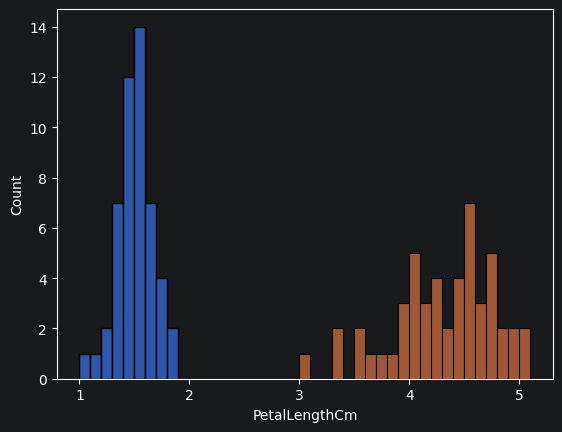

In [29]:
sns.histplot(iris_setosa["PetalLengthCm"], binwidth=0.1)
sns.histplot(iris_versicolor["PetalLengthCm"], binwidth=0.1)
plt.show()

仮説の設定

$H_0$：SetosaとVersicolorの花弁の長さの平均値に有意な差はない。

$H_1$：SetosaとVersicolorの花弁の長さの平均値に有意な差がある。

片側検定か両側検定かを確認する

平均値に差があるかどうかだけを検定し、どちらの品種の花弁が長いかは問題にしないため、両側検定を行う。

有意水準の設定

有意水準を0.05に設定する。

#### t値とp値の計算

In [30]:
t_stat, p_value = ttest_ind(iris_setosa["PetalLengthCm"], iris_versicolor["PetalLengthCm"])
print(t_stat, p_value)

-39.46866259397272 5.717463758170638e-62


結論：p値が有意水準0.05を下回るため、帰無仮説を棄却する。したがって、SetosaとVersicolorの花弁の長さの平均値には統計的に有意な差がある。

### 花弁の幅の分析

SetosaとVersicolorの花弁の幅の分布は、以下のとおりである。

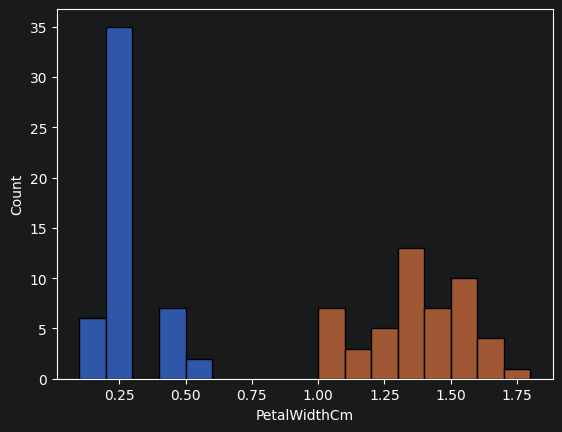

In [31]:
sns.histplot(iris_setosa["PetalWidthCm"], binwidth=0.1)
sns.histplot(iris_versicolor["PetalWidthCm"], binwidth=0.1)
plt.show()

仮説の設定

$H_0$：SetosaとVersicolorの花弁の幅の平均値に有意な差はない。

$H_1$：SetosaとVersicolorの花弁の幅の平均値に有意な差がある。

片側検定か両側検定かを確認する

平均値に差があるかどうかだけを検定し、どちらの品種の花弁が広いかは問題にしないため、両側検定を行う。

有意水準の設定

有意水準を0.05に設定する。

#### t値とp値の計算

In [32]:
t_stat, p_value = ttest_ind(iris_setosa["PetalWidthCm"], iris_versicolor["PetalWidthCm"])
print(t_stat, p_value)

-34.01237858829048 4.5890806157108925e-56


結論：値が有意水準0.05を下回るため、帰無仮説を棄却する。したがって、SetosaとVersicolorの花弁の幅の平均値には統計的に有意な差がある。

結論：推測統計の計算結果から、SetosaとVersicolorでは、がく片および花弁の長さと幅の平均値のすべてに統計的に有意な差があることが分かった。